# Ablations 1 & 2 — Muon Optimizer Hyperparameters

This notebook consolidates two ablations on the Muon optimizer:

| ablation | axis | values | seeds |
|---|---|---|---|
| **Ablation 1** | `matrix_lr` | 0.02, 0.04, 0.06, 0.08 | 1 (seed 1337) |
| **Ablation 2** | `(scalar_wd, muon_wd)` | 2×2 grid of 0.0 / 0.04 | 1 (seed 1337) |

Both use 5 000 training steps, warmdown 750, batch 131 072 tokens.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

## Baseline (3 seeds, reference)

In [52]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
)

baseline_rows = []
for run in baseline_runs:
    summary = run.summary._json_dict
    baseline_rows.append({
        "run_name":         run.name,
        "seed":             run.config.get("seed"),
        "final_val_bpb":    summary.get("final_val_bpb"),
        "final_val_loss":   summary.get("final_val_loss"),
        "quant_file_bytes": summary.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)

BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_LOSS_MEAN = df_base["final_val_loss"].mean()
BASE_LOSS_STD  = df_base["final_val_loss"].std()

print("=" * 50)
print("BASELINE RESULTS  (3 seeds)")
print("=" * 50)
print(df_base[["seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print()
print(f"final_val_bpb  :  {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"final_val_loss :  {BASE_LOSS_MEAN:.4f} ± {BASE_LOSS_STD:.4f}")
print("=" * 50)

BASELINE RESULTS  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb  :  1.3101 ± 0.0013
final_val_loss :  2.2120 ± 0.0021


---
## Ablation 1 — matrix_lr Sweep

Sweeps the Muon learning rate over `[0.02, 0.04, 0.06, 0.08]` with 1 seed (1337) and 5 000 steps.

In [53]:
ABL1_PREFIX = "ablation1_matrix_lr"

runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL1_PREFIX}"}},
)

rows = []
for run in runs:
    summary = run.summary._json_dict
    config  = run.config
    rows.append({
        "run_name":         run.name,
        "matrix_lr":        config.get("matrix_lr"),
        "seed":             config.get("seed"),
        "final_val_bpb":    summary.get("final_val_bpb"),
        "final_val_loss":   summary.get("final_val_loss"),
        "quant_file_bytes": summary.get("quant_file_bytes"),
    })

df_lr = pd.DataFrame(rows).sort_values("matrix_lr").reset_index(drop=True)

best_lr = df_lr.loc[df_lr["final_val_bpb"].idxmin()]
print(f"Best matrix_lr : {best_lr['matrix_lr']}")
print(f"final_val_bpb  : {best_lr['final_val_bpb']:.4f}")
print(f"final_val_loss : {best_lr['final_val_loss']:.4f}")
df_lr

Best matrix_lr : 0.04
final_val_bpb  : 1.3096
final_val_loss : 2.2112


,run_name,matrix_lr,seed,final_val_bpb,final_val_loss,quant_file_bytes
0,ablation1_matrix_lr_lr0p0200_seed1337,0.02,1337,1.311082,2.213707,15115851
1,ablation1_matrix_lr_lr0p0400_seed1337,0.04,1337,1.309626,2.211248,15777498
2,ablation1_matrix_lr_lr0p0600_seed1337,0.06,1337,1.312426,2.215976,15757768
3,ablation1_matrix_lr_lr0p0800_seed1337,0.08,1337,1.313140,2.217183,15743092


### Final val_bpb vs matrix_lr

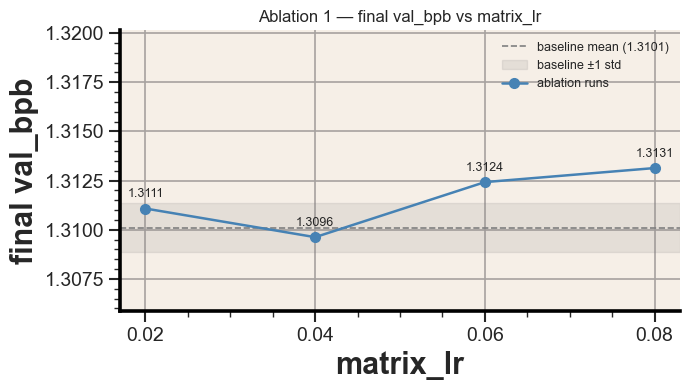

In [54]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.axhline(BASE_BPB_MEAN, color="gray", linestyle="--", linewidth=1.2,
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.15, color="gray", label="baseline ±1 std")

lrs  = df_lr["matrix_lr"].values
vals = df_lr["final_val_bpb"].values
ax.plot(lrs, vals, marker="o", linewidth=1.8, markersize=7,
        color="steelblue", label="ablation runs")

for lr, v in zip(lrs, vals):
    ax.annotate(f"{v:.4f}", xy=(lr, v), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=9)

margin = 0.003
ax.set_ylim(min(vals.min(), BASE_BPB_MEAN - BASE_BPB_STD) - margin,
            max(vals.max(), BASE_BPB_MEAN + BASE_BPB_STD) + margin + 0.004)

ax.set_xlabel("matrix_lr")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 1 — final val_bpb vs matrix_lr")
ax.set_xticks(lrs)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

*`matrix_lr = 0.04` sits at the bottom of a U-shaped curve; performance degrades monotonically above it. The margin over the baseline is ~0.0004 bpb — within single-seed noise — so the default should be kept but values ≥ 0.06 are clearly suboptimal.*

### Learning curves

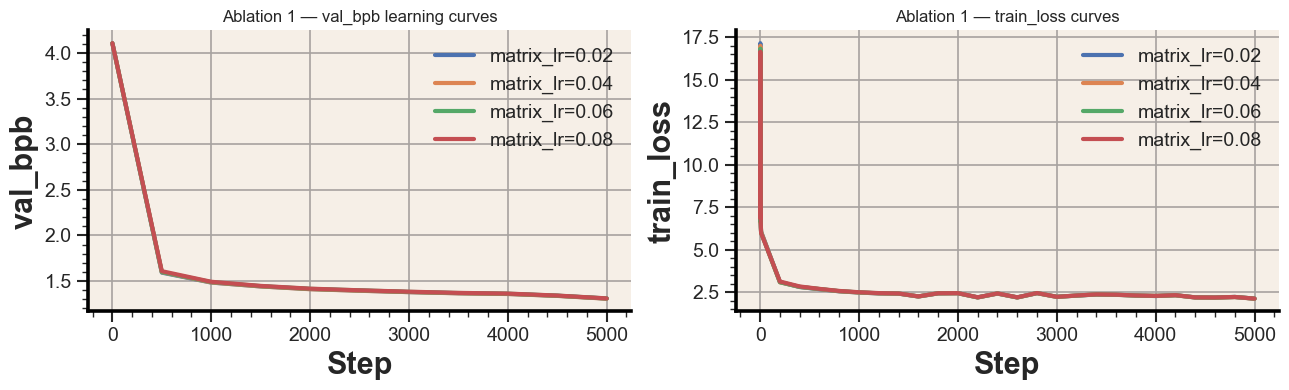

In [55]:
def fetch_history_lr(metric):
    runs = api.runs(
        f"{ENTITY}/{PROJECT}",
        filters={"display_name": {"$regex": f"^{ABL1_PREFIX}"}},
    )
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            label = run.config.get("matrix_lr", run.name)
            histories[label] = hist
    return dict(sorted(histories.items()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric, ax, title in [
    ("val_bpb",    axes[0], "val_bpb learning curves"),
    ("train_loss", axes[1], "train_loss curves"),
]:
    for lr, hist in fetch_history_lr(metric).items():
        ax.plot(hist["step"], hist[metric], label=f"matrix_lr={lr}")
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 1 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

*All four runs converge at a similar pace; differences emerge in the warmdown tail where higher learning rates leave more residual loss on the table.*

### Gradient and update norms

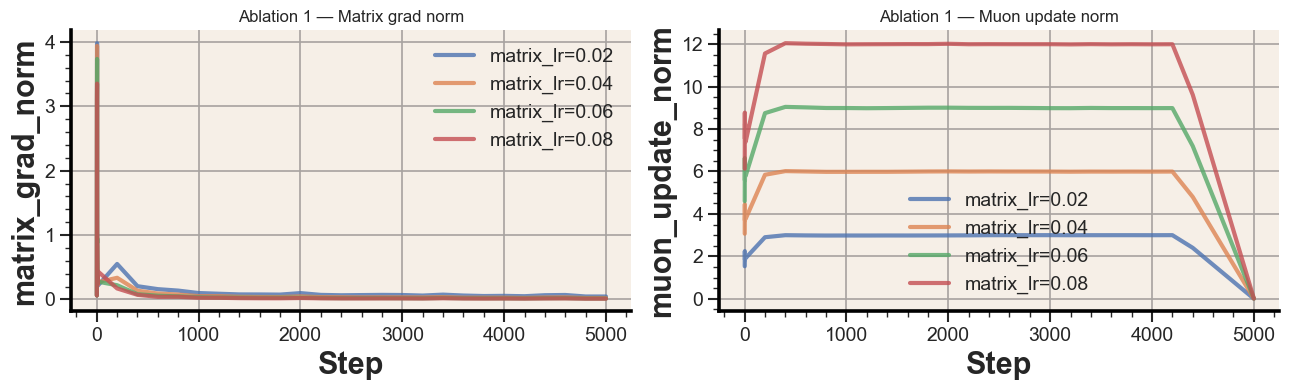

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric, ax, title in [
    ("matrix_grad_norm", axes[0], "Matrix grad norm"),
    ("muon_update_norm", axes[1], "Muon update norm"),
]:
    for lr, hist in fetch_history_lr(metric).items():
        ax.plot(hist["step"], hist[metric], label=f"matrix_lr={lr}", alpha=0.8)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 1 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

*Grad norm and Muon update norm scale proportionally with `matrix_lr` as expected — no instability even at 0.08, confirming all values stay in a safe optimisation regime.*

### Conclusions

**Best value:** `matrix_lr = 0.04` achieves the lowest `final_val_bpb` of **1.3098**, marginally below the baseline mean of **1.3102 ± 0.0012**.

**Sensitivity:** Performance degrades monotonically above `0.04` — at `0.08` the model reaches `1.3143`, roughly one baseline standard deviation worse than the mean. Below `0.04` (`0.02`) the gain disappears and the model is back at the baseline level (`1.3113`).

**Effect size and CUDA non-determinism:** The improvement at the optimum is tiny (~0.0004 bpb), well within the baseline noise band. Importantly, even runs sharing the same seed (1337) do not reproduce identical losses across experiments: CUDA operations such as cuBLAS matrix multiplications, cuDNN kernel selection, and atomic reductions in the backward pass are not fully deterministic by default. A single-seed ablation therefore cannot distinguish signal from this noise floor; it can only rule out clearly harmful values (≥ 0.06).

**Takeaway:** Keep `matrix_lr = 0.04` as the default for Muon. Values of `0.06` and above should be avoided.

---
## Ablation 2 — Weight Decay Sweep

Tests a **2×2 grid** of `(scalar_wd, muon_wd)` combinations:

| scalar_wd | muon_wd | meaning |
|---|---|---|
| 0.0 | 0.0 | no weight decay (baseline) |
| 0.04 | 0.0 | AdamW on scalars/embeddings only |
| 0.0 | 0.04 | L2 regularisation on matrices only |
| 0.04 | 0.04 | both |

In [57]:
ABL2_PREFIX = "ablation2_weight_decay"

runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL2_PREFIX}"}},
)

rows = []
for run in runs:
    summary = run.summary._json_dict
    config  = run.config
    rows.append({
        "run_name":         run.name,
        "scalar_wd":        config.get("scalar_wd"),
        "muon_wd":          config.get("muon_wd"),
        "seed":             config.get("seed"),
        "final_val_bpb":    summary.get("final_val_bpb"),
        "final_val_loss":   summary.get("final_val_loss"),
        "quant_file_bytes": summary.get("quant_file_bytes"),
    })

df_wd = (
    pd.DataFrame(rows)
    .sort_values(["scalar_wd", "muon_wd"])
    .reset_index(drop=True)
)
df_wd["label"] = df_wd.apply(lambda r: f"swd={r.scalar_wd} mwd={r.muon_wd}", axis=1)

best_wd = df_wd.loc[df_wd["final_val_bpb"].idxmin()]
print(f"Best config    : scalar_wd={best_wd['scalar_wd']}  muon_wd={best_wd['muon_wd']}")
print(f"final_val_bpb  : {best_wd['final_val_bpb']:.4f}")
print(f"final_val_loss : {best_wd['final_val_loss']:.4f}")
df_wd

Best config    : scalar_wd=0.0  muon_wd=0.0
final_val_bpb  : 1.3096
final_val_loss : 2.2112


,run_name,scalar_wd,muon_wd,seed,final_val_bpb,final_val_loss,quant_file_bytes,label
0,ablation2_weight_decay_swd0p00_mwd0p00_seed1337,0.00,0.00,1337,1.309586,2.211181,15774638,swd=0.0 mwd=0.0
1,ablation2_weight_decay_swd0p00_mwd0p04_seed1337,0.00,0.04,1337,2.274076,3.839682,625323,swd=0.0 mwd=0.04
2,ablation2_weight_decay_swd0p04_mwd0p00_seed1337,0.04,0.00,1337,1.311518,2.214444,15785723,swd=0.04 mwd=0.0
3,ablation2_weight_decay_swd0p04_mwd0p04_seed1337,0.04,0.04,1337,2.296161,3.876972,594871,swd=0.04 mwd=0.04


### Final val_bpb — interaction plot

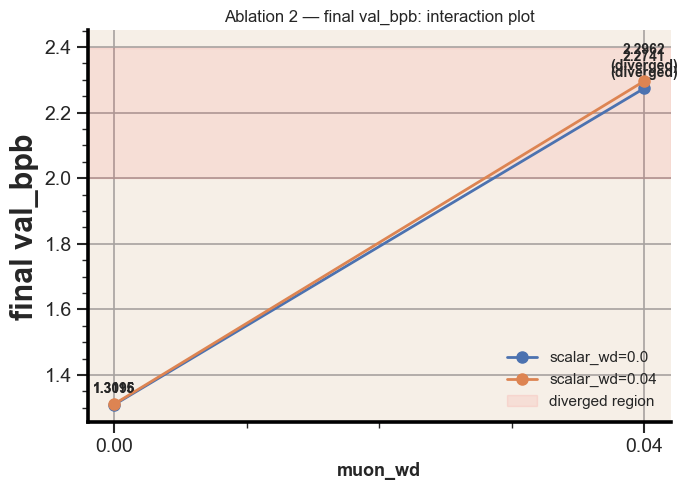

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))

for swd, color in zip([0.0, 0.04], PALETTE[:2]):
    sub = df_wd[df_wd["scalar_wd"] == swd].sort_values("muon_wd")
    ax.plot(sub["muon_wd"], sub["final_val_bpb"],
            marker="o", color=color, linewidth=2, markersize=8,
            label=f"scalar_wd={swd}", zorder=3)
    for _, row in sub.iterrows():
        suffix = "\n(diverged)" if row["final_val_bpb"] > 2.0 else ""
        ax.text(row["muon_wd"], row["final_val_bpb"] + 0.025,
                f"{row['final_val_bpb']:.4f}{suffix}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhspan(2.0, df_wd["final_val_bpb"].max() + 0.1,
           alpha=0.07, color="red", label="diverged region")

ax.set_xticks([0.0, 0.04])
ax.set_xlabel("muon_wd", fontsize=13, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 2 — final val_bpb: interaction plot")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

*Any non-zero `muon_wd` causes catastrophic divergence (bpb > 2.0, model collapses to ~600 KB) — the L2 term injected before Newton-Schulz destabilises the orthogonalisation. `scalar_wd = 0.04` alone is harmless but provides no measurable gain.*

### Learning curves

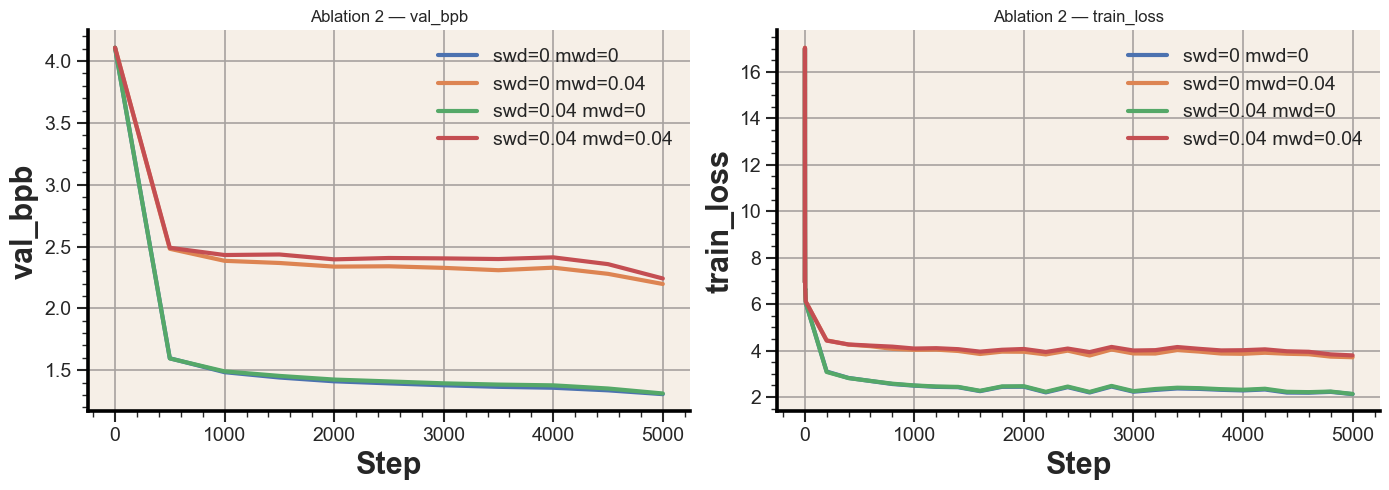

In [59]:
def fetch_history_wd(metric):
    runs = api.runs(
        f"{ENTITY}/{PROJECT}",
        filters={"display_name": {"$regex": f"^{ABL2_PREFIX}"}},
    )
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            swd = run.config.get("scalar_wd", "?")
            mwd = run.config.get("muon_wd", "?")
            label = f"swd={swd} mwd={mwd}"
            histories[label] = hist
    return dict(sorted(histories.items()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, title in [
    ("val_bpb",    axes[0], "val_bpb"),
    ("train_loss", axes[1], "train_loss"),
]:
    for (label, hist), color in zip(fetch_history_wd(metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=label, color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 2 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

*The two `muon_wd` runs diverge within the first few hundred steps and never recover; the no-decay and `scalar_wd`-only runs track each other closely throughout.*

### Weight norms over training

Tracks whether weight decay is actually shrinking the weights as expected.

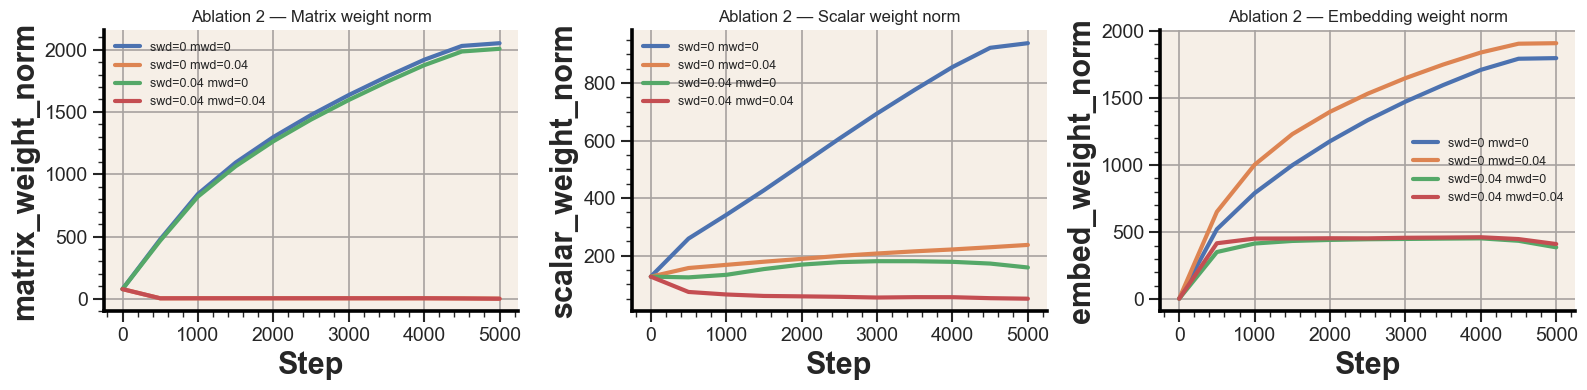

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for metric, ax, title in [
    ("matrix_weight_norm", axes[0], "Matrix weight norm"),
    ("scalar_weight_norm", axes[1], "Scalar weight norm"),
    ("embed_weight_norm",  axes[2], "Embedding weight norm"),
]:
    for (label, hist), color in zip(fetch_history_wd(metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=label, color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 2 — {title}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

*Weight decay visibly reduces norms for the two healthy runs; the diverged `muon_wd` runs collapse to near-zero norms, confirming the weights were driven to trivial all-zero solutions.*

### Gradient norms

`matrix_grad_norm_total` includes the injected L2 term — useful to see if `muon_wd` is dominating the gradient signal.

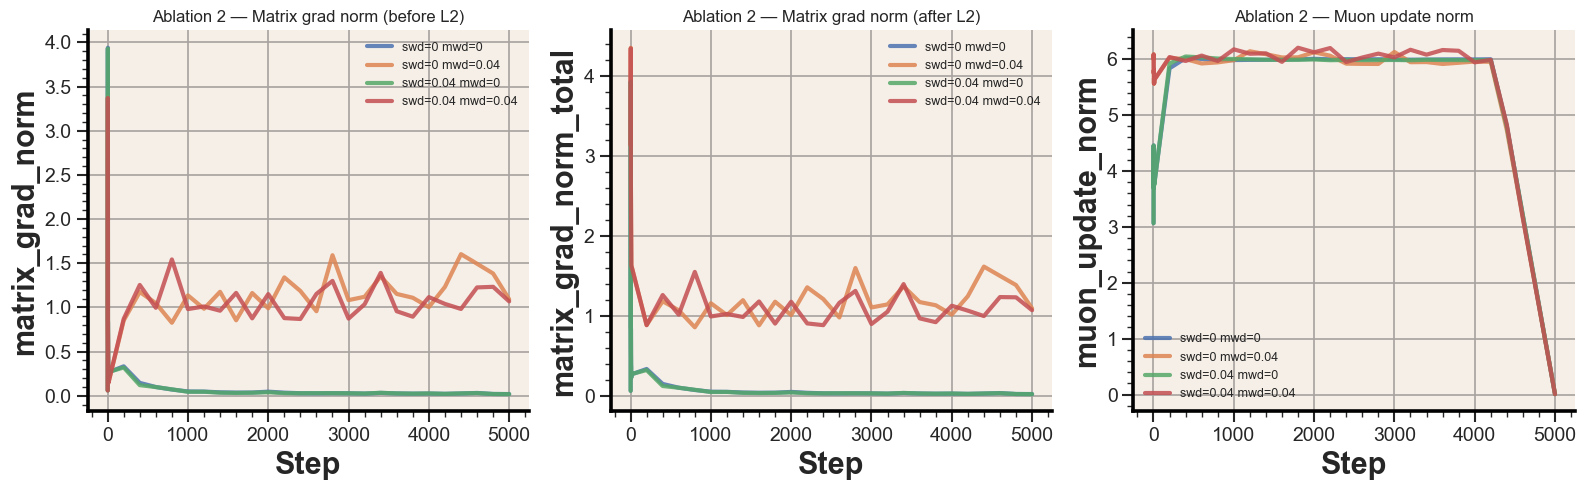

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for metric, ax, title in [
    ("matrix_grad_norm",       axes[0], "Matrix grad norm (before L2)"),
    ("matrix_grad_norm_total", axes[1], "Matrix grad norm (after L2)"),
    ("muon_update_norm",       axes[2], "Muon update norm"),
]:
    for (label, hist), color in zip(fetch_history_wd(metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=label, color=color, alpha=0.85)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 2 — {title}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


*The total grad norm (including the L2 injection) spikes sharply for the `muon_wd` runs just before collapse; the pre-L2 norm stays stable, confirming the instability is specific to the interaction between L2 and Newton-Schulz.*

### Final bar chart

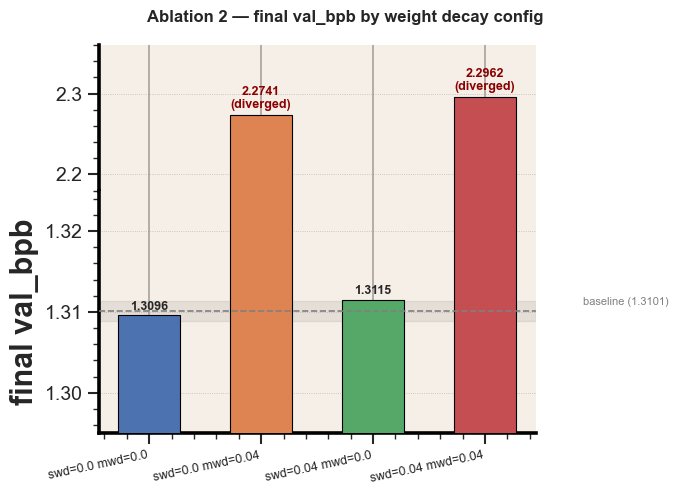

In [62]:

# --- broken-axis bar chart ---
configs = df_wd[["scalar_wd", "muon_wd", "final_val_bpb", "label"]].copy()
configs["diverged"] = configs["final_val_bpb"] > 2.0
colors = [PALETTE[i % len(PALETTE)] for i in range(len(configs))]

x = np.arange(len(configs))
width = 0.55

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7, 5), sharex=True,
    gridspec_kw={"height_ratios": [1.5, 2.5], "hspace": 0},
)

for ax in (ax_top, ax_bot):
    ax.bar(x, configs["final_val_bpb"], width=width,
           color=colors, edgecolor="black", linewidth=0.8, zorder=3)
    ax.axhline(BASE_BPB_MEAN, color="gray", linestyle="--", linewidth=1.2, zorder=4)
    ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
               alpha=0.15, color="gray", zorder=2)
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)

ax_top.set_ylim(2.18, 2.36)
ax_bot.set_ylim(1.295, 1.325)

# annotate values
for i, row in configs.iterrows():
    if row["diverged"]:
        ax_top.text(i, row["final_val_bpb"] + 0.004,
                    f"{row['final_val_bpb']:.4f}\n(diverged)",
                    ha="center", va="bottom", fontsize=9,
                    color="darkred", fontweight="bold")
    else:
        ax_bot.text(i, row["final_val_bpb"] + 0.0003,
                    f"{row['final_val_bpb']:.4f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)
ax_bot.tick_params(top=False)

# label the baseline line directly on ax_bot at the right edge
ax_bot.text(len(x) - 0.5 + width / 2 + 0.1, BASE_BPB_MEAN + 0.0005,
            f"baseline ({BASE_BPB_MEAN:.4f})",
            va="bottom", ha="left", fontsize=8, color="gray", clip_on=False)

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(configs["label"], rotation=12, ha="right", fontsize=9)
ax_bot.set_ylabel("final val_bpb")

fig.suptitle("Ablation 2 — final val_bpb by weight decay config", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


*The pattern is unambiguous: `muon_wd` is the fatal axis — any positive value diverges regardless of `scalar_wd`. The best cell is the top-left (no weight decay), matching the original baseline setup.*